In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
import matplotlib.pyplot as plt
import os
import numpy as np
import nglview as nv
from simple_mda import *
import pickle
from scipy.stats import gaussian_kde

/home/zengk/miniforge3/envs/biol0041/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
WT_r1 = mda.Universe("data/WT_r1.tpr", "data/WT_r1.xtc")
D166N_r1 = mda.Universe("data/D166N_r1.tpr", "data/D166N_r1.xtc")
WT_r2 = mda.Universe("data/WT_r2.tpr", "data/WT_r2.xtc")
D166N_r2 = mda.Universe("data/D166N_r2.tpr", "data/D166N_r2.xtc")
WT_r3 = mda.Universe("data/WT_r3.tpr", "data/WT_r3.xtc")
D166N_r3 = mda.Universe("data/D166N_r3.tpr", "data/D166N_r3.xtc")

In [3]:
def system_dist(systems, res1, res2, atom1, atom2, pairs, save=None):
    chain_length = 408


    dist_data = {}

    for sys_name, repeats in systems.items():

        dist_data[sys_name] = {}

        for pair_label, (i,j) in pairs.items():

            repeat_dists = []

            for u in repeats:

                res1_correct = res1 + i * chain_length
                res2_correct = res2 + j * chain_length

                d = simple_dist_any(u, res1_correct, res2_correct, atom1=atom1, atom2=atom2)

                repeat_dists.append(d)

            dist_data[sys_name][pair_label] = repeat_dists

    if save:
        with open(save, "wb") as f:
            pickle.dump(dist_data, f)
    
    return(dist_data)


In [4]:
pairs = {
        "AD": (0,3)
    }

system_WT = {
        "WT": [WT_r1, WT_r2, WT_r3],
    }

system_D166N = {
        "D166N": [D166N_r1, D166N_r2, D166N_r3],
    }


WT_T133_dist = system_dist(system_WT, 47, 14, "CG", "OG1", pairs, "WT_T133_dist.pkl", )
WT_Q134_dist = system_dist(system_WT, 47, 15, "CG", "NE2", pairs, "WT_Q134_dist.pkl")
WT_T137_dist = system_dist(system_WT, 47, 18, "CG", "OG1", pairs, "WT_T137_dist.pkl")
WT_Q180_dist = system_dist(system_WT, 47, 61, "CG", "NE2", pairs, "WT_Q180_dist.pkl")

D166N_T133_dist = system_dist(system_D166N, 47, 14, "CG", "OG1", pairs, "D166N_T133_dist.pkl")
D166N_Q134_dist = system_dist(system_D166N, 47, 15, "CG", "NE2", pairs, "D166N_Q134_dist.pkl")
D166N_T137_dist = system_dist(system_D166N, 47, 18, "CG", "OG1", pairs, "D166N_T137_dist.pkl")
D166N_Q180_dist = system_dist(system_D166N, 47, 61, "CG", "NE2", pairs, "D166N_Q180_dist.pkl")


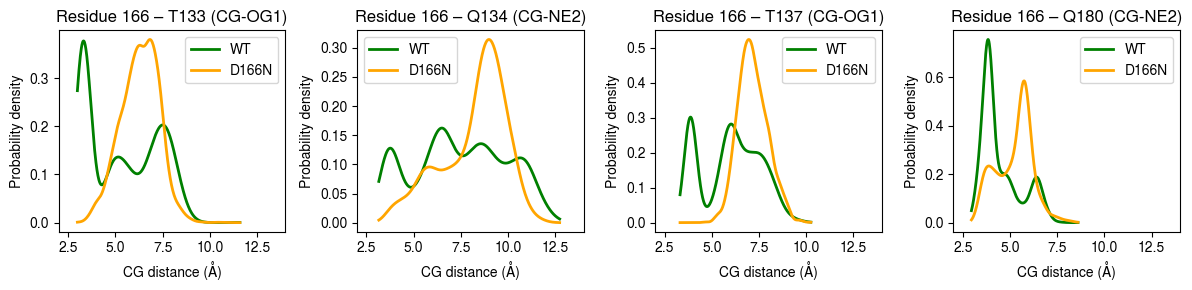

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import os


files = [
    ("results/WT_T133_dist.pkl", "results/D166N_T133_dist.pkl"),
    ("results/WT_Q134_dist.pkl", "results/D166N_Q134_dist.pkl"),
    ("results/WT_T137_dist.pkl", "results/D166N_T137_dist.pkl"),
    ("results/WT_Q180_dist.pkl", "results/D166N_Q180_dist.pkl"),
]

titles = [
    "Residue 166 – T133 (CG-OG1)",
    "Residue 166 – Q134 (CG-NE2)",
    "Residue 166 – T137 (CG-OG1)",
    "Residue 166 – Q180 (CG-NE2)"
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes = axes.flatten()

for i, (wt_file, d166n_file) in enumerate(files):

    with open(wt_file, "rb") as f:
        WT_data = pickle.load(f)

    with open(d166n_file, "rb") as f:
        D166N_data = pickle.load(f)


    WT_all = np.concatenate(WT_data["WT"]["AD"])
    D166N_all = np.concatenate(D166N_data["D166N"]["AD"])

    WT_kde = gaussian_kde(WT_all)
    D166N_kde = gaussian_kde(D166N_all)

    all_data = np.concatenate([WT_all, D166N_all])
    x = np.linspace(all_data.min(), all_data.max(), 500)

    ax = axes[i]

    ax.plot(x, WT_kde(x), linewidth=2, label="WT",color= "green")
    ax.plot(x, D166N_kde(x), linewidth=2, label="D166N",color= "orange")

    ax.set_title(titles[i])
    ax.set_xlabel("CG distance (Å)")
    ax.set_ylabel("Probability density")
    ax.set_xlim(2, 14)

    ax.legend()

plt.tight_layout()
plt.show()